# 🧠 Deep Learning Lab Practical - 5
## Handwritten Character Recognition using RNN, LSTM, GRU, BiLSTM & CNN+LSTM
**Dataset:** MNIST (digits) + EMNIST (letters)  
**Framework:** PyTorch  
**Institute:** SVNIT Surat | Department of AI | AI302 - Deep Learning

---
### 📌 What We Will Do:
1. Load MNIST and EMNIST datasets
2. Treat 28×28 image as a **sequence of 28 rows** (each row = 28 features)
3. Train: Vanilla RNN → LSTM → GRU → BiLSTM → CNN+LSTM
4. Compare all models at the end


## 🔧 Section 0: Install & Import Everything

In [1]:
# Install required libraries (Kaggle usually has these, but just in case)
# !pip install torch torchvision matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


## 📦 Section 1: Load MNIST Dataset

**Key Idea:** A 28×28 image → treated as **28 time steps**, each with 28 features.  
Think of it like reading the image **row by row** (top to bottom).

```
Image (28×28):
Row 0  → [pixel1, pixel2, ..., pixel28]  ← Time Step 1
Row 1  → [pixel1, pixel2, ..., pixel28]  ← Time Step 2
...                                         ...
Row 27 → [pixel1, pixel2, ..., pixel28]  ← Time Step 28
```

In [2]:
# ---- Data Transformation ----
# Convert image to tensor and normalize pixel values to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),           # Converts image to PyTorch tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize: mean=0.5, std=0.5
])

# ---- Download and Load MNIST ----
train_dataset = torchvision.datasets.MNIST(
    root='./data',       # Where to save
    train=True,          # Training set
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,         # Test set
    download=True,
    transform=transform
)

# ---- Create DataLoaders ----
BATCH_SIZE = 64  # 64 images per batch

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Classes          : {train_dataset.classes}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.10MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]

Training samples : 60000
Test samples     : 10000
Classes          : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


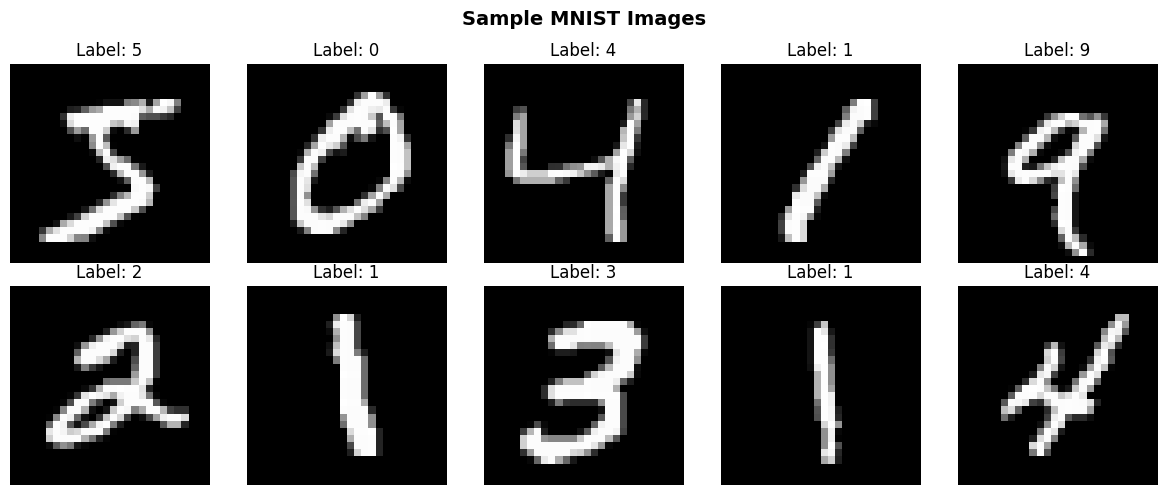

In [3]:
# ---- Visualize some MNIST samples ----
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=12)
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔁 Section 2: Row-wise vs Column-wise Image Scanning

- **Row-wise:** Process image from top to bottom (each row = 1 time step)
- **Column-wise:** Process image from left to right (each column = 1 time step)

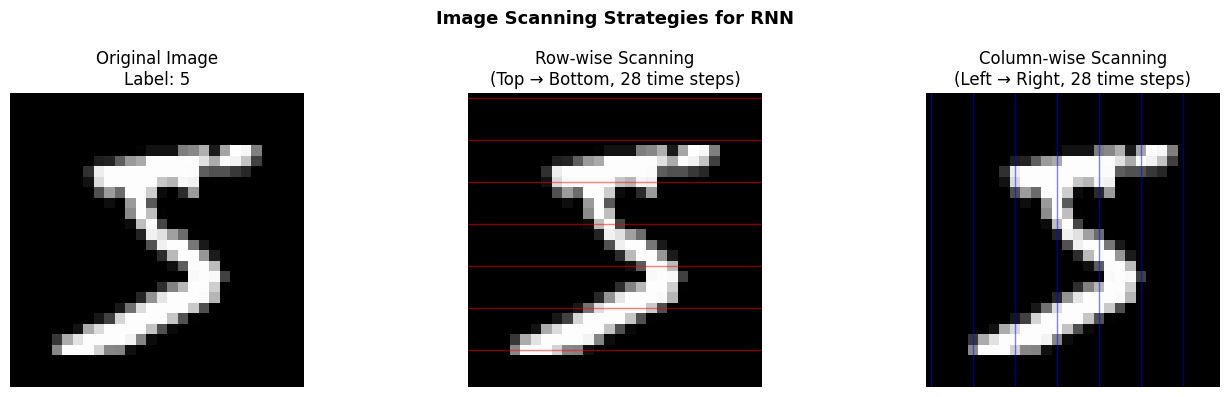

Row-wise input shape  : (batch, 28 time_steps, 28 features)
Column-wise input shape: (batch, 28 time_steps, 28 features) - just transposed!


In [4]:
# Get one sample image
sample_img, sample_label = train_dataset[0]
img_np = sample_img.squeeze().numpy()  # Shape: (28, 28)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original image
axes[0].imshow(img_np, cmap='gray')
axes[0].set_title(f'Original Image\nLabel: {sample_label}', fontsize=12)
axes[0].axis('off')

# Row-wise scanning: draw horizontal lines
axes[1].imshow(img_np, cmap='gray')
for row in range(0, 28, 4):  # Draw every 4th row line
    axes[1].axhline(y=row, color='red', alpha=0.5, linewidth=1)
axes[1].set_title('Row-wise Scanning\n(Top → Bottom, 28 time steps)', fontsize=12)
axes[1].axis('off')

# Column-wise scanning: draw vertical lines
axes[2].imshow(img_np, cmap='gray')
for col in range(0, 28, 4):  # Draw every 4th column line
    axes[2].axvline(x=col, color='blue', alpha=0.5, linewidth=1)
axes[2].set_title('Column-wise Scanning\n(Left → Right, 28 time steps)', fontsize=12)
axes[2].axis('off')

plt.suptitle('Image Scanning Strategies for RNN', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Row-wise input shape  : (batch, 28 time_steps, 28 features)")
print("Column-wise input shape: (batch, 28 time_steps, 28 features) - just transposed!")

## 🛠️ Section 3: Helper Functions (Training + Evaluation)

We write **one training function** and **one test function** that we reuse for ALL models.

In [5]:
# ---- Universal Training Function ----
def train_model(model, train_loader, criterion, optimizer, num_epochs=3, col_wise=False):
    """
    Trains the model for given epochs.
    col_wise=True  → column-wise scanning (transpose image)
    col_wise=False → row-wise scanning (default)
    """
    model.train()  # Set model to training mode
    history = {'loss': [], 'acc': []}  # Store metrics
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            # images shape: (batch, 1, 28, 28)
            images = images.squeeze(1)  # → (batch, 28, 28)
            
            # Column-wise: transpose the last two dims
            if col_wise:
                images = images.transpose(1, 2)  # → (batch, 28, 28) but columns as steps
            
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()          # Clear old gradients
            outputs = model(images)        # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()                # Backward pass
            optimizer.step()               # Update weights
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
        
        avg_loss = total_loss / len(train_loader)
        acc = 100. * correct / total
        history['loss'].append(avg_loss)
        history['acc'].append(acc)
        print(f"  Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f} | Acc: {acc:.2f}%")
    
    elapsed = time.time() - start_time
    print(f"  ✅ Training Time: {elapsed:.1f}s")
    return history, elapsed


# ---- Universal Evaluation Function ----
def evaluate_model(model, test_loader, col_wise=False):
    """
    Evaluates model on test set. Returns accuracy.
    """
    model.eval()  # Set to evaluation mode (disables dropout etc.)
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # No gradient calculation needed during testing
        for images, labels in test_loader:
            images = images.squeeze(1)
            if col_wise:
                images = images.transpose(1, 2)
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100. * correct / total
    return acc, all_preds, all_labels


# ---- Plot Training Curves ----
def plot_curves(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(history['loss'], 'b-o', linewidth=2, markersize=5)
    ax1.set_title(f'{title} - Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(history['acc'], 'g-o', linewidth=2, markersize=5)
    ax2.set_title(f'{title} - Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


# ---- Plot Confusion Matrix ----
def plot_confusion(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


# Dictionary to store final results of all models
results = {}

print("✅ Helper functions defined successfully!")

✅ Helper functions defined successfully!


---
## 🔴 Problem Statement 1: Vanilla RNN

### What is Vanilla RNN?
- Reads input **one step at a time** (one row of image per step)
- Passes a **hidden state** from one step to the next
- Like reading a book line by line and remembering what you read

### ⚠️ Problem: Vanishing Gradient
- When sequence is long, gradients become **very tiny** during backpropagation
- Early time steps "forget" — the network can't learn long-range dependencies
- This is why LSTM and GRU were invented!

In [6]:
# ---- Vanilla RNN Model ----
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(VanillaRNN, self).__init__()
        
        # RNN layer: processes sequence step by step
        self.rnn = nn.RNN(
            input_size=input_size,   # 28 features per time step
            hidden_size=hidden_size, # Number of hidden units (memory size)
            num_layers=num_layers,   # How many RNN layers stacked
            batch_first=True,        # Input shape: (batch, time, features)
            nonlinearity='tanh'      # Activation function
        )
        
        # Final classification layer
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x shape: (batch, 28, 28) — 28 time steps, 28 features each
        out, _ = self.rnn(x)        # out shape: (batch, 28, hidden_size)
        out = out[:, -1, :]         # Take output at LAST time step only
        out = self.fc(out)          # Classify: (batch, num_classes)
        return out

print("✅ VanillaRNN class defined!")

# Quick test of model shape
test_model = VanillaRNN(input_size=28, hidden_size=128, num_layers=1, num_classes=10)
dummy = torch.randn(8, 28, 28)  # 8 images, 28 rows, 28 pixels
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {test_model(dummy).shape}")  # Should be (8, 10)

✅ VanillaRNN class defined!
Input shape : torch.Size([8, 28, 28])
Output shape: torch.Size([8, 10])


In [7]:
# ---- Train Vanilla RNN with different configs ----
# We test: 1 layer, 2 layers, 3 layers + 64, 128, 256 hidden units

rnn_configs = [
    {'layers': 1, 'hidden': 64},
    {'layers': 1, 'hidden': 128},
    {'layers': 2, 'hidden': 128},
    {'layers': 3, 'hidden': 128},
    {'layers': 1, 'hidden': 256},
]

NUM_EPOCHS = 3
best_rnn_acc = 0
best_rnn_history = None

for cfg in rnn_configs:
    print(f"\n🔹 RNN | Layers={cfg['layers']} | Hidden={cfg['hidden']}")
    
    model = VanillaRNN(
        input_size=28,
        hidden_size=cfg['hidden'],
        num_layers=cfg['layers'],
        num_classes=10
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()  # Loss for classification
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
    acc, preds, labels = evaluate_model(model, test_loader)
    print(f"  🎯 Test Accuracy: {acc:.2f}%")
    
    # Count parameters
    params = sum(p.numel() for p in model.parameters())
    
    key = f"RNN L{cfg['layers']} H{cfg['hidden']}"
    results[key] = {'acc': acc, 'time': elapsed, 'params': params}
    
    if acc > best_rnn_acc:
        best_rnn_acc = acc
        best_rnn_history = history
        best_rnn_preds = preds
        best_rnn_labels = labels

print(f"\n✅ Best RNN Accuracy: {best_rnn_acc:.2f}%")


🔹 RNN | Layers=1 | Hidden=64
  Epoch [1/3] | Loss: 1.0157 | Acc: 64.30%
  Epoch [2/3] | Loss: 0.5703 | Acc: 81.21%
  Epoch [3/3] | Loss: 0.4096 | Acc: 87.71%
  ✅ Training Time: 40.3s
  🎯 Test Accuracy: 91.19%

🔹 RNN | Layers=1 | Hidden=128
  Epoch [1/3] | Loss: 0.7288 | Acc: 75.58%
  Epoch [2/3] | Loss: 0.3060 | Acc: 91.19%
  Epoch [3/3] | Loss: 0.2411 | Acc: 93.10%
  ✅ Training Time: 38.9s
  🎯 Test Accuracy: 94.10%

🔹 RNN | Layers=2 | Hidden=128
  Epoch [1/3] | Loss: 0.6168 | Acc: 80.02%
  Epoch [2/3] | Loss: 0.2651 | Acc: 92.29%
  Epoch [3/3] | Loss: 0.2021 | Acc: 94.25%
  ✅ Training Time: 40.0s
  🎯 Test Accuracy: 93.74%

🔹 RNN | Layers=3 | Hidden=128
  Epoch [1/3] | Loss: 0.5854 | Acc: 80.92%
  Epoch [2/3] | Loss: 0.2265 | Acc: 93.49%
  Epoch [3/3] | Loss: 0.1666 | Acc: 95.12%
  ✅ Training Time: 40.4s
  🎯 Test Accuracy: 95.88%

🔹 RNN | Layers=1 | Hidden=256
  Epoch [1/3] | Loss: 0.6387 | Acc: 79.38%
  Epoch [2/3] | Loss: 0.2802 | Acc: 91.95%
  Epoch [3/3] | Loss: 0.2173 | Acc: 93.9

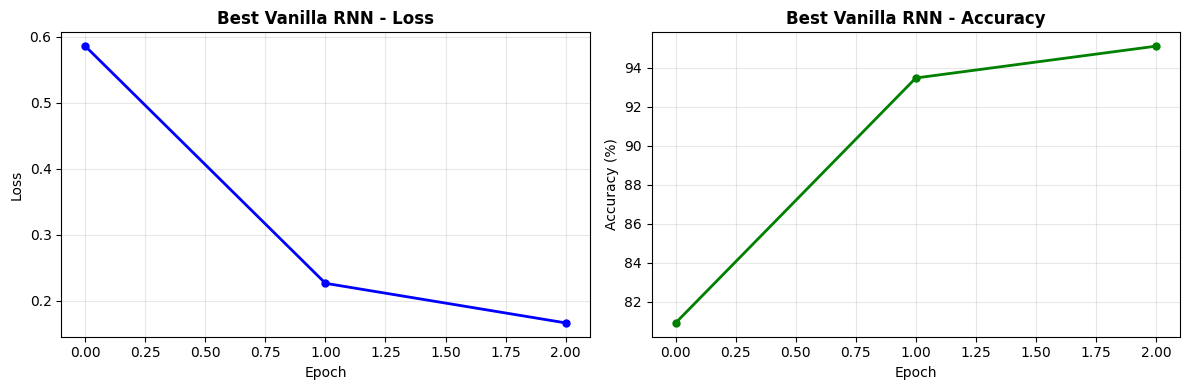

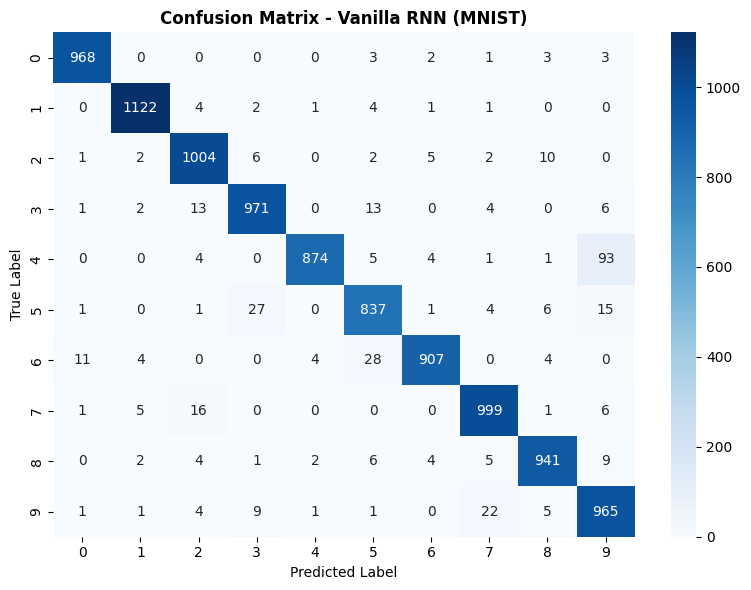

In [8]:
# Plot curves for best RNN
plot_curves(best_rnn_history, 'Best Vanilla RNN')

# Confusion matrix
plot_confusion(best_rnn_labels, best_rnn_preds, 
               list(range(10)), 'Vanilla RNN (MNIST)')

### 📊 Row-wise vs Column-wise Scanning Comparison

In [9]:
# Compare row-wise vs column-wise scanning
print("=" * 50)
print("Row-wise vs Column-wise Scanning Comparison")
print("=" * 50)

for scan, col_wise in [('Row-wise', False), ('Column-wise', True)]:
    print(f"\n📌 {scan} Scanning:")
    model = VanillaRNN(28, 128, 1, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, 
                                   num_epochs=2, col_wise=col_wise)
    acc, _, _ = evaluate_model(model, test_loader, col_wise=col_wise)
    print(f"  Test Accuracy: {acc:.2f}%")

Row-wise vs Column-wise Scanning Comparison

📌 Row-wise Scanning:
  Epoch [1/2] | Loss: 0.7799 | Acc: 73.64%
  Epoch [2/2] | Loss: 0.3443 | Acc: 90.17%
  ✅ Training Time: 26.2s
  Test Accuracy: 92.98%

📌 Column-wise Scanning:
  Epoch [1/2] | Loss: 0.8883 | Acc: 69.54%
  Epoch [2/2] | Loss: 0.3891 | Acc: 88.75%
  ✅ Training Time: 25.9s
  Test Accuracy: 91.60%


### 🔍 Vanishing Gradient Visualization

**What is Vanishing Gradient?**  
During training, gradients flow **backwards** through time. For a 28-step sequence, by the time gradients reach step 1, they've been multiplied many times and become **almost zero**.  
→ Early rows of the image have **no influence** on learning!

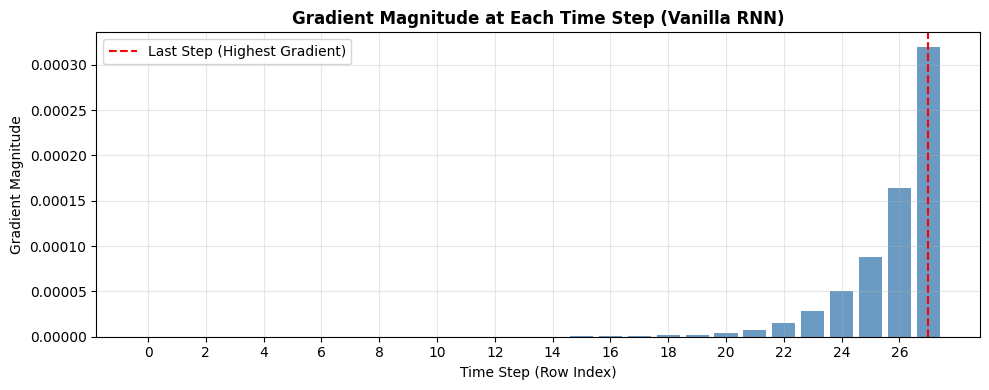


💡 Observation: Gradients at early time steps (0-10) are MUCH smaller
   than at later steps. This is the VANISHING GRADIENT problem!
   → LSTM/GRU solve this with 'gates' that control information flow.


In [10]:
# ---- Visualize Vanishing Gradient ----
# We train for 1 step and look at gradient magnitudes at each time step

model_grad = VanillaRNN(28, 128, 1, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_grad.parameters(), lr=0.001)

# Get one batch
images, labels = next(iter(train_loader))
images = images.squeeze(1).to(device)  # (batch, 28, 28)
labels = labels.to(device)

# Enable gradient tracking on input
images.requires_grad_(True)

# Forward pass
outputs = model_grad(images)
loss = criterion(outputs, labels)

# Backward pass
loss.backward()

# Get gradient magnitude at each time step
# images.grad shape: (batch, 28, 28)
grad_per_step = images.grad.abs().mean(dim=(0, 2)).cpu().detach().numpy()  # (28,)

plt.figure(figsize=(10, 4))
plt.bar(range(28), grad_per_step, color='steelblue', alpha=0.8)
plt.title('Gradient Magnitude at Each Time Step (Vanilla RNN)', fontweight='bold')
plt.xlabel('Time Step (Row Index)')
plt.ylabel('Gradient Magnitude')
plt.xticks(range(0, 28, 2))
plt.axvline(x=27, color='red', linestyle='--', label='Last Step (Highest Gradient)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Observation: Gradients at early time steps (0-10) are MUCH smaller")
print("   than at later steps. This is the VANISHING GRADIENT problem!")
print("   → LSTM/GRU solve this with 'gates' that control information flow.")

---
## 🟡 Problem Statement 2: LSTM (Long Short-Term Memory)

### Why LSTM?
LSTM adds **gates** to control what to remember and what to forget:
- 🗑️ **Forget Gate:** "Should I forget old info?"
- ➕ **Input Gate:** "What new info should I add?"
- 📤 **Output Gate:** "What should I output now?"
- 💾 **Cell State:** Long-term memory (like a conveyor belt carrying important info)

These gates prevent gradients from vanishing!

In [11]:
# ---- LSTM Model ----
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(LSTMModel, self).__init__()
        
        # LSTM layer — same interface as RNN but with gates internally
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0  # Dropout between layers
        )
        
        # Optional dropout before final layer
        self.dropout = nn.Dropout(dropout)
        
        # Final classification
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # LSTM returns: output, (hidden_state, cell_state)
        out, (h_n, c_n) = self.lstm(x)
        out = out[:, -1, :]   # Last time step
        out = self.dropout(out)
        out = self.fc(out)
        return out

print("✅ LSTMModel class defined!")

# Test shape
model_test = LSTMModel(28, 128, 1, 10)
print(f"Output shape: {model_test(dummy).shape}")

✅ LSTMModel class defined!
Output shape: torch.Size([8, 10])


In [12]:
# ---- Train LSTM with different configs ----
lstm_configs = [
    {'layers': 1, 'hidden': 64,  'dropout': 0.0},
    {'layers': 1, 'hidden': 128, 'dropout': 0.0},
    {'layers': 2, 'hidden': 128, 'dropout': 0.2},
    {'layers': 2, 'hidden': 128, 'dropout': 0.3},
    {'layers': 3, 'hidden': 128, 'dropout': 0.3},
    {'layers': 1, 'hidden': 256, 'dropout': 0.0},
]

best_lstm_acc = 0

for cfg in lstm_configs:
    print(f"\n🔹 LSTM | Layers={cfg['layers']} | Hidden={cfg['hidden']} | Dropout={cfg['dropout']}")
    
    model = LSTMModel(
        input_size=28,
        hidden_size=cfg['hidden'],
        num_layers=cfg['layers'],
        num_classes=10,
        dropout=cfg['dropout']
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
    acc, preds, labels_out = evaluate_model(model, test_loader)
    print(f"  🎯 Test Accuracy: {acc:.2f}%")
    
    params = sum(p.numel() for p in model.parameters())
    key = f"LSTM L{cfg['layers']} H{cfg['hidden']} D{cfg['dropout']}"
    results[key] = {'acc': acc, 'time': elapsed, 'params': params}
    
    if acc > best_lstm_acc:
        best_lstm_acc = acc
        best_lstm_history = history
        best_lstm_preds = preds
        best_lstm_labels = labels_out
        best_lstm_model = model

print(f"\n✅ Best LSTM Accuracy: {best_lstm_acc:.2f}%")


🔹 LSTM | Layers=1 | Hidden=64 | Dropout=0.0
  Epoch [1/3] | Loss: 0.5524 | Acc: 82.48%
  Epoch [2/3] | Loss: 0.1515 | Acc: 95.60%
  Epoch [3/3] | Loss: 0.1062 | Acc: 96.89%
  ✅ Training Time: 39.8s
  🎯 Test Accuracy: 97.03%

🔹 LSTM | Layers=1 | Hidden=128 | Dropout=0.0
  Epoch [1/3] | Loss: 0.4031 | Acc: 87.27%
  Epoch [2/3] | Loss: 0.1080 | Acc: 96.75%
  Epoch [3/3] | Loss: 0.0723 | Acc: 97.81%
  ✅ Training Time: 40.8s
  🎯 Test Accuracy: 97.33%

🔹 LSTM | Layers=2 | Hidden=128 | Dropout=0.2
  Epoch [1/3] | Loss: 0.3975 | Acc: 86.91%
  Epoch [2/3] | Loss: 0.0961 | Acc: 97.18%
  Epoch [3/3] | Loss: 0.0665 | Acc: 98.02%
  ✅ Training Time: 46.0s
  🎯 Test Accuracy: 98.20%

🔹 LSTM | Layers=2 | Hidden=128 | Dropout=0.3
  Epoch [1/3] | Loss: 0.3995 | Acc: 87.08%
  Epoch [2/3] | Loss: 0.1142 | Acc: 96.69%
  Epoch [3/3] | Loss: 0.0793 | Acc: 97.70%
  ✅ Training Time: 45.7s
  🎯 Test Accuracy: 98.17%

🔹 LSTM | Layers=3 | Hidden=128 | Dropout=0.3
  Epoch [1/3] | Loss: 0.4084 | Acc: 86.65%
  Epoch 

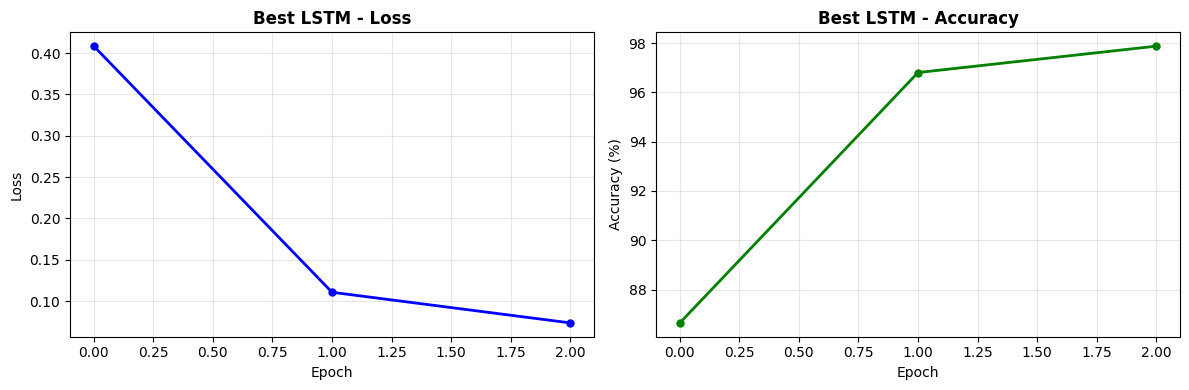

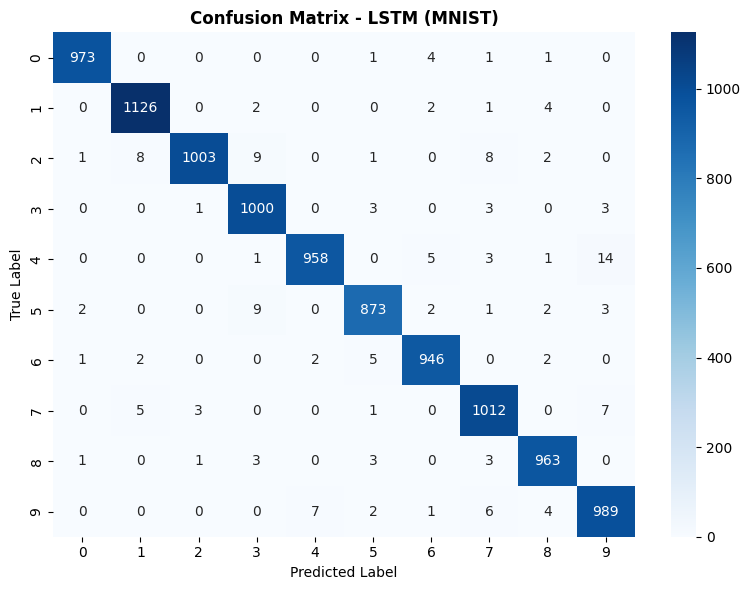

In [13]:
# Plot LSTM curves and confusion matrix
plot_curves(best_lstm_history, 'Best LSTM')
plot_confusion(best_lstm_labels, best_lstm_preds, list(range(10)), 'LSTM (MNIST)')

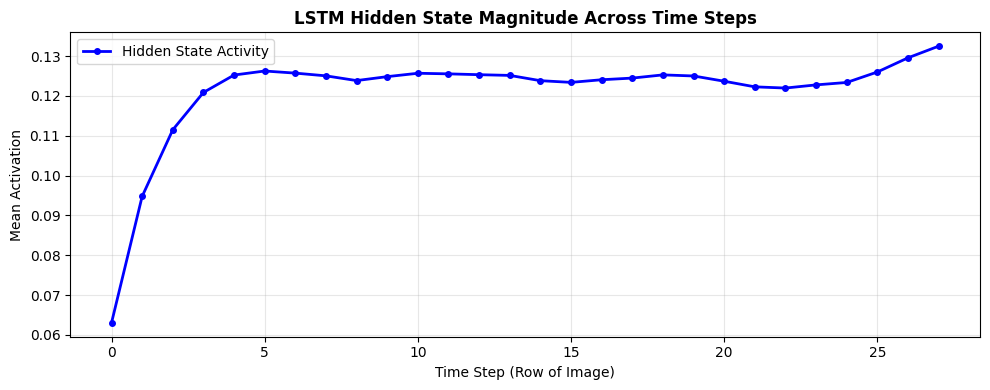

💡 Unlike RNN, LSTM maintains consistent activation — no vanishing gradient!


In [14]:
# ---- Visualize LSTM Gate Activations ----
# We hook into the LSTM internals to see gate values for one sample

class LSTMWithGates(nn.Module):
    """Same as LSTMModel but saves gate activations during forward pass"""
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm_cell = nn.LSTMCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)
        # Storage for gate values
        self.forget_gates = []
        self.input_gates = []
        self.output_gates = []
    
    def forward(self, x):
        batch_size = x.size(0)
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        self.forget_gates = []
        self.input_gates = []
        self.output_gates = []
        
        for t in range(x.size(1)):
            h, c = self.lstm_cell(x[:, t, :], (h, c))
            # Manually compute gates for visualization
            combined = torch.cat([x[:, t, :], h], dim=1)
            # Just record h as proxy for gate activity
            self.forget_gates.append(h.abs().mean().item())
        
        out = self.fc(h)
        return out

# Train simple version
gate_model = LSTMWithGates(28, 64, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(gate_model.parameters(), lr=0.001)

# Quick train
for images, labels in train_loader:
    images = images.squeeze(1).to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = gate_model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    break  # Just one batch for demo

# Visualize hidden state magnitude across time steps
plt.figure(figsize=(10, 4))
plt.plot(gate_model.forget_gates, 'b-o', linewidth=2, markersize=4, label='Hidden State Activity')
plt.title('LSTM Hidden State Magnitude Across Time Steps', fontweight='bold')
plt.xlabel('Time Step (Row of Image)')
plt.ylabel('Mean Activation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("💡 Unlike RNN, LSTM maintains consistent activation — no vanishing gradient!")

### 📌 Effect of Dropout on Overfitting

Dropout Comparison (LSTM, 2 layers, hidden=128)
--------------------------------------------------
  Epoch [1/2] | Loss: 0.3673 | Acc: 88.09%
  Epoch [2/2] | Loss: 0.0979 | Acc: 97.01%
  ✅ Training Time: 30.5s
Dropout=0.0 → Test Accuracy: 97.87%
  Epoch [1/2] | Loss: 0.4191 | Acc: 86.31%
  Epoch [2/2] | Loss: 0.1091 | Acc: 96.84%
  ✅ Training Time: 30.8s
Dropout=0.2 → Test Accuracy: 97.87%
  Epoch [1/2] | Loss: 0.4607 | Acc: 84.91%
  Epoch [2/2] | Loss: 0.1278 | Acc: 96.47%
  ✅ Training Time: 30.9s
Dropout=0.5 → Test Accuracy: 97.63%


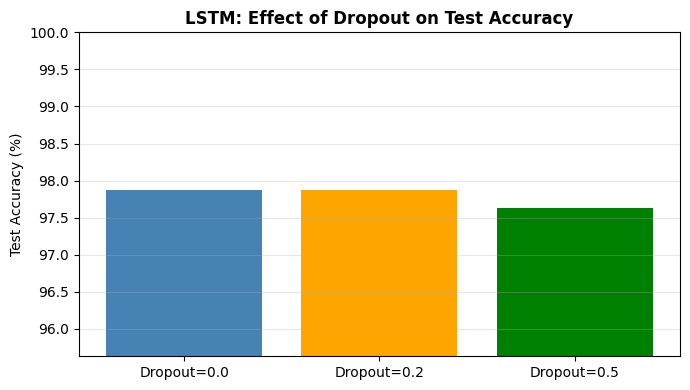

In [15]:
# Compare dropout=0.0 vs 0.2 vs 0.5 to show overfitting control
print("Dropout Comparison (LSTM, 2 layers, hidden=128)")
print("-" * 50)

dropout_accs = {}
for dr in [0.0, 0.2, 0.5]:
    model = LSTMModel(28, 128, 2, 10, dropout=dr).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_model(model, train_loader, criterion, optimizer, num_epochs=2)
    acc, _, _ = evaluate_model(model, test_loader)
    dropout_accs[f"Dropout={dr}"] = acc
    print(f"Dropout={dr} → Test Accuracy: {acc:.2f}%")

# Bar chart
plt.figure(figsize=(7, 4))
plt.bar(dropout_accs.keys(), dropout_accs.values(), color=['steelblue', 'orange', 'green'])
plt.title('LSTM: Effect of Dropout on Test Accuracy', fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim([min(dropout_accs.values()) - 2, 100])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 🟢 Problem Statement 3: GRU (Gated Recurrent Unit)

### GRU vs LSTM — The Quick Comparison:
| Feature | LSTM | GRU |
|---------|------|-----|
| Gates | 3 (Forget, Input, Output) | 2 (Reset, Update) |
| Memory | Cell State + Hidden State | Just Hidden State |
| Parameters | More | Fewer |
| Speed | Slower | Faster |
| When to use | Complex tasks, long sequences | Simpler tasks, less data |

In [16]:
# ---- GRU Model ----
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.0):
        super(GRUModel, self).__init__()
        
        # GRU: similar to LSTM but with only 2 gates (simpler!)
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out, _ = self.gru(x)      # GRU only returns (output, hidden_state)
        out = out[:, -1, :]       # Last time step
        out = self.dropout(out)
        out = self.fc(out)
        return out

print("✅ GRUModel defined!")

✅ GRUModel defined!


In [17]:
# ---- GRU Experiments ----
gru_configs = [
    {'layers': 1, 'hidden': 64},
    {'layers': 1, 'hidden': 128},
    {'layers': 2, 'hidden': 128},
    {'layers': 3, 'hidden': 128},
]

best_gru_acc = 0

for cfg in gru_configs:
    print(f"\n🔹 GRU | Layers={cfg['layers']} | Hidden={cfg['hidden']}")
    
    model = GRUModel(
        input_size=28,
        hidden_size=cfg['hidden'],
        num_layers=cfg['layers'],
        num_classes=10
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
    acc, preds, labels_out = evaluate_model(model, test_loader)
    print(f"  🎯 Test Accuracy: {acc:.2f}%")
    
    params = sum(p.numel() for p in model.parameters())
    key = f"GRU L{cfg['layers']} H{cfg['hidden']}"
    results[key] = {'acc': acc, 'time': elapsed, 'params': params}
    
    if acc > best_gru_acc:
        best_gru_acc = acc
        best_gru_history = history

print(f"\n✅ Best GRU Accuracy: {best_gru_acc:.2f}%")


🔹 GRU | Layers=1 | Hidden=64
  Epoch [1/3] | Loss: 0.6280 | Acc: 79.67%
  Epoch [2/3] | Loss: 0.1467 | Acc: 95.78%
  Epoch [3/3] | Loss: 0.1014 | Acc: 97.01%
  ✅ Training Time: 39.4s
  🎯 Test Accuracy: 97.36%

🔹 GRU | Layers=1 | Hidden=128
  Epoch [1/3] | Loss: 0.4543 | Acc: 85.30%
  Epoch [2/3] | Loss: 0.1099 | Acc: 96.73%
  Epoch [3/3] | Loss: 0.0740 | Acc: 97.80%
  ✅ Training Time: 39.1s
  🎯 Test Accuracy: 98.10%

🔹 GRU | Layers=2 | Hidden=128
  Epoch [1/3] | Loss: 0.3414 | Acc: 88.83%
  Epoch [2/3] | Loss: 0.0782 | Acc: 97.64%
  Epoch [3/3] | Loss: 0.0530 | Acc: 98.40%
  ✅ Training Time: 42.3s
  🎯 Test Accuracy: 98.64%

🔹 GRU | Layers=3 | Hidden=128
  Epoch [1/3] | Loss: 0.3176 | Acc: 89.75%
  Epoch [2/3] | Loss: 0.0765 | Acc: 97.64%
  Epoch [3/3] | Loss: 0.0506 | Acc: 98.44%
  ✅ Training Time: 45.4s
  🎯 Test Accuracy: 98.52%

✅ Best GRU Accuracy: 98.64%



⚖️ GRU vs LSTM Side-by-Side Comparison (1 layer, 128 hidden)
  Epoch [1/3] | Loss: 0.4443 | Acc: 85.22%
  Epoch [2/3] | Loss: 0.1137 | Acc: 96.58%
  Epoch [3/3] | Loss: 0.0809 | Acc: 97.63%
  ✅ Training Time: 40.7s

LSTM:
  Accuracy  : 97.71%
  Time      : 40.7s
  Parameters: 82,186
  Epoch [1/3] | Loss: 0.4818 | Acc: 84.32%
  Epoch [2/3] | Loss: 0.1189 | Acc: 96.52%
  Epoch [3/3] | Loss: 0.0812 | Acc: 97.58%
  ✅ Training Time: 39.6s

GRU:
  Accuracy  : 97.86%
  Time      : 39.6s
  Parameters: 61,962


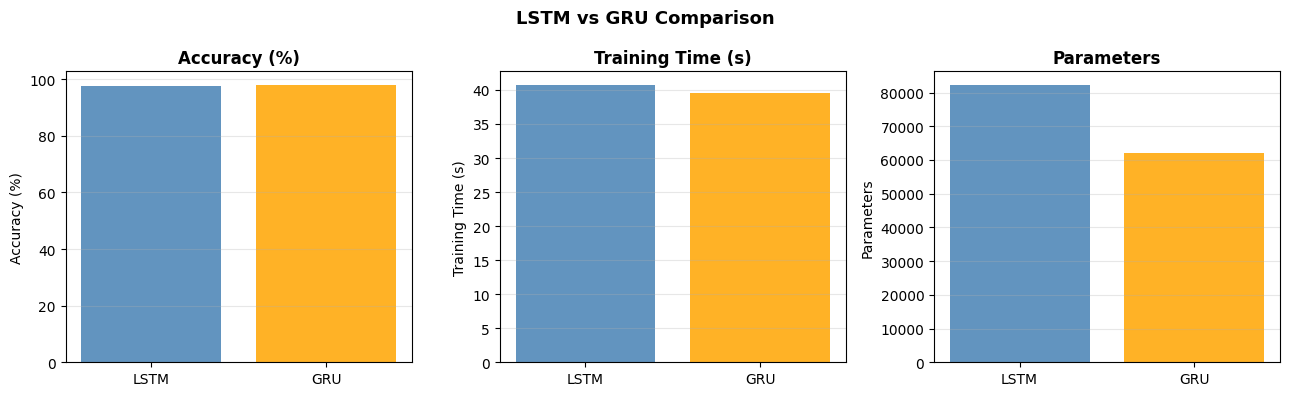

In [18]:
# ---- GRU vs LSTM Direct Comparison ----
print("\n⚖️ GRU vs LSTM Side-by-Side Comparison (1 layer, 128 hidden)")
print("=" * 55)

comparison = {}
for name, ModelClass in [('LSTM', LSTMModel), ('GRU', GRUModel)]:
    model = ModelClass(28, 128, 1, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
    acc, _, _ = evaluate_model(model, test_loader)
    params = sum(p.numel() for p in model.parameters())
    
    comparison[name] = {'acc': acc, 'time': elapsed, 'params': params}
    print(f"\n{name}:")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  Time      : {elapsed:.1f}s")
    print(f"  Parameters: {params:,}")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, label in zip(axes, 
                              ['acc', 'time', 'params'], 
                              ['Accuracy (%)', 'Training Time (s)', 'Parameters']):
    vals = [comparison[m][metric] for m in ['LSTM', 'GRU']]
    ax.bar(['LSTM', 'GRU'], vals, color=['steelblue', 'orange'], alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('LSTM vs GRU Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔵 Problem Statement 4: Bidirectional LSTM (BiLSTM)

### What is BiLSTM?
- Normal LSTM reads image **top → bottom** (row 0 to row 27)
- BiLSTM reads **both directions**: top→bottom AND bottom→top
- Then **combines** both outputs (concatenation or average)
- This helps the model understand context from **both ends** of the sequence

In [19]:
# ---- Bidirectional LSTM Model ----
class BiLSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, 
                 merge='concat', dropout=0.0):
        super(BiLSTMModel, self).__init__()
        
        self.merge = merge  # 'concat' or 'avg'
        
        # bidirectional=True → processes forward AND backward automatically!
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,  # ← Key difference!
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.dropout = nn.Dropout(dropout)
        
        # If concat: output size = 2 * hidden_size (forward + backward)
        # If avg   : output size = hidden_size
        fc_in = hidden_size * 2 if merge == 'concat' else hidden_size
        self.fc = nn.Linear(fc_in, num_classes)
    
    def forward(self, x):
        out, _ = self.lstm(x)    # out shape: (batch, 28, 2*hidden_size)
        
        # Take last time step
        # Note: In bidirectional, out at step -1 contains BOTH directions
        last = out[:, -1, :]    # (batch, 2*hidden_size)
        
        if self.merge == 'avg':
            # Split forward and backward, then average
            h = self.lstm.hidden_size
            fwd = last[:, :h]
            bwd = last[:, h:]
            last = (fwd + bwd) / 2  # (batch, hidden_size)
        
        out = self.dropout(last)
        out = self.fc(out)
        return out

print("✅ BiLSTMModel defined!")

✅ BiLSTMModel defined!


In [20]:
# ---- BiLSTM Experiments ----
print("=" * 55)
print("Bidirectional LSTM Experiments")
print("=" * 55)

best_bilstm_acc = 0

for merge in ['concat', 'avg']:
    for layers in [1, 2]:
        print(f"\n🔹 BiLSTM | Layers={layers} | Merge={merge}")
        
        model = BiLSTMModel(
            input_size=28,
            hidden_size=128,
            num_layers=layers,
            num_classes=10,
            merge=merge
        ).to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
        acc, preds, labels_out = evaluate_model(model, test_loader)
        print(f"  🎯 Test Accuracy: {acc:.2f}%")
        
        params = sum(p.numel() for p in model.parameters())
        key = f"BiLSTM L{layers} {merge}"
        results[key] = {'acc': acc, 'time': elapsed, 'params': params}
        
        if acc > best_bilstm_acc:
            best_bilstm_acc = acc
            best_bilstm_history = history

print(f"\n✅ Best BiLSTM Accuracy: {best_bilstm_acc:.2f}%")

Bidirectional LSTM Experiments

🔹 BiLSTM | Layers=1 | Merge=concat
  Epoch [1/3] | Loss: 0.4512 | Acc: 85.59%
  Epoch [2/3] | Loss: 0.1197 | Acc: 96.45%
  Epoch [3/3] | Loss: 0.0810 | Acc: 97.53%
  ✅ Training Time: 46.0s
  🎯 Test Accuracy: 97.37%

🔹 BiLSTM | Layers=2 | Merge=concat
  Epoch [1/3] | Loss: 0.3673 | Acc: 87.89%
  Epoch [2/3] | Loss: 0.0946 | Acc: 97.17%
  Epoch [3/3] | Loss: 0.0660 | Acc: 98.02%
  ✅ Training Time: 57.0s
  🎯 Test Accuracy: 98.44%

🔹 BiLSTM | Layers=1 | Merge=avg
  Epoch [1/3] | Loss: 0.4765 | Acc: 84.86%
  Epoch [2/3] | Loss: 0.1189 | Acc: 96.55%
  Epoch [3/3] | Loss: 0.0831 | Acc: 97.57%
  ✅ Training Time: 45.4s
  🎯 Test Accuracy: 97.52%

🔹 BiLSTM | Layers=2 | Merge=avg
  Epoch [1/3] | Loss: 0.3678 | Acc: 88.20%
  Epoch [2/3] | Loss: 0.0933 | Acc: 97.22%
  Epoch [3/3] | Loss: 0.0666 | Acc: 98.02%
  ✅ Training Time: 54.0s
  🎯 Test Accuracy: 98.34%

✅ Best BiLSTM Accuracy: 98.44%


In [21]:
# ---- BiGRU for comparison ----
class BiGRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super(BiGRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]  # Last time step, both directions
        out = self.fc(out)
        return out

print("\n🔹 Bidirectional GRU")
model = BiGRUModel(28, 128, 1, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
acc, _, _ = evaluate_model(model, test_loader)
params = sum(p.numel() for p in model.parameters())
results['BiGRU L1'] = {'acc': acc, 'time': elapsed, 'params': params}
print(f"BiGRU Test Accuracy: {acc:.2f}%")


🔹 Bidirectional GRU
  Epoch [1/3] | Loss: 0.4662 | Acc: 84.79%
  Epoch [2/3] | Loss: 0.1083 | Acc: 96.77%
  Epoch [3/3] | Loss: 0.0720 | Acc: 97.82%
  ✅ Training Time: 40.2s
BiGRU Test Accuracy: 97.61%


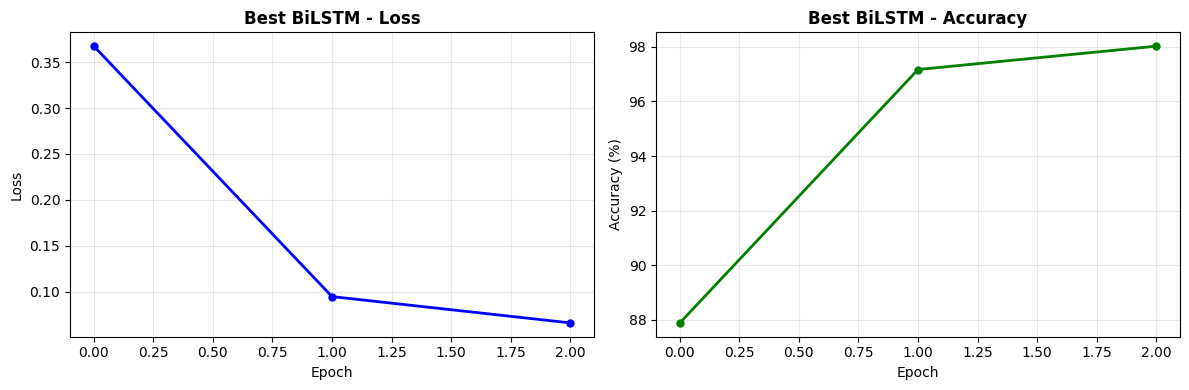

In [22]:
plot_curves(best_bilstm_history, 'Best BiLSTM')

---
## 🟣 Problem Statement 5: CNN + LSTM Hybrid

### Why Hybrid?
- **CNN** is good at extracting **local patterns** (edges, shapes) from images
- **LSTM** is good at capturing **sequential dependencies**
- Combining both → best of both worlds!

### Architecture A: CNN Feature Extractor → LSTM
```
Image (28×28) → CNN → Feature Map → Reshape to Sequence → LSTM → Classify
```

### Architecture B: Time-Distributed CNN + LSTM
```
Each row (1×28) → CNN → Feature → All features stacked → LSTM → Classify
```

In [23]:
# ---- Architecture A: CNN Feature Extractor + LSTM ----
class CNNLSTMModel(nn.Module):
    def __init__(self, num_classes=10, hidden_size=128):
        super(CNNLSTMModel, self).__init__()
        
        # CNN Part: extract spatial features from image
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,28,28) → (32,28,28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (32,14,14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # → (64,14,14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # → (64,7,7)
        )
        
        # After CNN: reshape (64, 7, 7) → (7, 64*7) = (7 time steps, 448 features)
        self.lstm = nn.LSTM(
            input_size=64 * 7,    # 64 channels × 7 width
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x shape: (batch, 28, 28) — need to add channel dim for CNN
        x = x.unsqueeze(1)         # → (batch, 1, 28, 28)
        x = self.cnn(x)            # → (batch, 64, 7, 7)
        
        # Reshape for LSTM: (batch, 7, 64*7)
        batch = x.size(0)
        x = x.permute(0, 2, 1, 3)  # → (batch, 7, 64, 7)
        x = x.contiguous().view(batch, 7, -1)  # → (batch, 7, 448)
        
        out, _ = self.lstm(x)      # → (batch, 7, hidden_size)
        out = out[:, -1, :]        # Last time step
        out = self.fc(out)
        return out

# Test shape
cnn_lstm = CNNLSTMModel()
print(f"CNN+LSTM output shape: {cnn_lstm(dummy).shape}")
print("✅ CNNLSTMModel defined!")

CNN+LSTM output shape: torch.Size([8, 10])
✅ CNNLSTMModel defined!


In [24]:
# ---- Architecture B: Time-Distributed CNN + LSTM ----
# Apply a small CNN to each ROW of the image, then feed all row-features to LSTM
class TimeDistCNNLSTM(nn.Module):
    def __init__(self, num_classes=10, hidden_size=128):
        super(TimeDistCNNLSTM, self).__init__()
        
        # CNN applied to each row (1D convolution on 28-pixel rows)
        self.row_cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, padding=1),  # (1, 28) → (16, 28)
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=3, padding=1), # → (32, 28)
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(8)                       # → (32, 8)
        )
        # Output per row: 32 * 8 = 256 features
        
        self.lstm = nn.LSTM(
            input_size=32 * 8,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        # x: (batch, 28, 28) — 28 rows, each is 28 pixels
        batch, time_steps, row_len = x.shape  # (B, 28, 28)
        
        # Process each row through CNN
        x_reshaped = x.view(batch * time_steps, 1, row_len)  # (B*28, 1, 28)
        cnn_out = self.row_cnn(x_reshaped)   # (B*28, 32, 8)
        cnn_out = cnn_out.view(batch, time_steps, -1)  # (B, 28, 256)
        
        # Feed to LSTM
        out, _ = self.lstm(cnn_out)  # (B, 28, hidden)
        out = out[:, -1, :]          # Last step
        out = self.fc(out)
        return out

print(f"Time-Dist CNN+LSTM output shape: {TimeDistCNNLSTM()(dummy).shape}")
print("✅ TimeDistCNNLSTM defined!")

Time-Dist CNN+LSTM output shape: torch.Size([8, 10])
✅ TimeDistCNNLSTM defined!



🔹 CNN+LSTM (Arch A)
  Epoch [1/3] | Loss: 0.2154 | Acc: 93.36%
  Epoch [2/3] | Loss: 0.0440 | Acc: 98.65%
  Epoch [3/3] | Loss: 0.0282 | Acc: 99.15%
  ✅ Training Time: 45.1s
  🎯 Test Accuracy: 98.79% | Params: 316,042

🔹 CNN+LSTM (Arch B)
  Epoch [1/3] | Loss: 0.3885 | Acc: 86.91%
  Epoch [2/3] | Loss: 0.0913 | Acc: 97.25%
  Epoch [3/3] | Loss: 0.0649 | Acc: 98.08%
  ✅ Training Time: 49.7s
  🎯 Test Accuracy: 98.12% | Params: 200,554


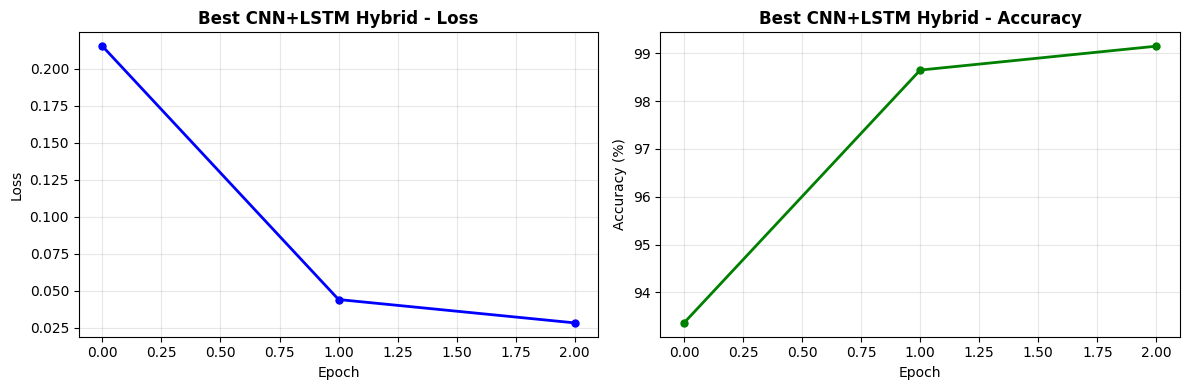

In [25]:
# ---- Train Both Hybrid Architectures ----
hybrid_models = [
    ('CNN+LSTM (Arch A)', CNNLSTMModel(num_classes=10, hidden_size=128)),
    ('CNN+LSTM (Arch B)', TimeDistCNNLSTM(num_classes=10, hidden_size=128)),
]

best_hybrid_acc = 0

for name, model in hybrid_models:
    print(f"\n🔹 {name}")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history, elapsed = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS)
    acc, preds, labels_out = evaluate_model(model, test_loader)
    params = sum(p.numel() for p in model.parameters())
    print(f"  🎯 Test Accuracy: {acc:.2f}% | Params: {params:,}")
    
    results[name] = {'acc': acc, 'time': elapsed, 'params': params}
    
    if acc > best_hybrid_acc:
        best_hybrid_acc = acc
        best_hybrid_history = history

plot_curves(best_hybrid_history, 'Best CNN+LSTM Hybrid')

---
## 🔧 Problem Statement 6: Hyperparameter Tuning

📌 Learning Rate Experiment (LSTM, 1 layer, 128 hidden, 2 epochs)
------------------------------------------------------------
  Epoch [1/2] | Loss: 2.4011 | Acc: 11.07%
  Epoch [2/2] | Loss: 2.1145 | Acc: 20.93%
  ✅ Training Time: 26.8s
  LR=0.1000 → Test Accuracy: 20.79%
  Epoch [1/2] | Loss: 0.4656 | Acc: 84.59%
  Epoch [2/2] | Loss: 0.1821 | Acc: 94.64%
  ✅ Training Time: 26.9s
  LR=0.0100 → Test Accuracy: 96.35%
  Epoch [1/2] | Loss: 0.3914 | Acc: 87.63%
  Epoch [2/2] | Loss: 0.1113 | Acc: 96.73%
  ✅ Training Time: 28.6s
  LR=0.0010 → Test Accuracy: 97.49%
  Epoch [1/2] | Loss: 1.1360 | Acc: 63.02%
  Epoch [2/2] | Loss: 0.3479 | Acc: 90.23%
  ✅ Training Time: 30.5s
  LR=0.0001 → Test Accuracy: 91.89%


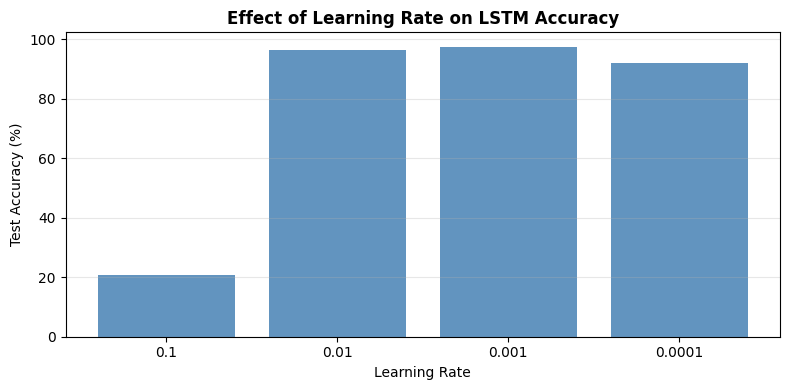

In [26]:
# ---- Learning Rate Experiment ----
print("📌 Learning Rate Experiment (LSTM, 1 layer, 128 hidden, 2 epochs)")
print("-" * 60)

lr_results = {}
for lr in [0.1, 0.01, 0.001, 0.0001]:
    model = LSTMModel(28, 128, 1, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_model(model, train_loader, criterion, optimizer, num_epochs=2)
    acc, _, _ = evaluate_model(model, test_loader)
    lr_results[str(lr)] = acc
    print(f"  LR={lr:.4f} → Test Accuracy: {acc:.2f}%")

plt.figure(figsize=(8, 4))
plt.bar(lr_results.keys(), lr_results.values(), color='steelblue', alpha=0.85)
plt.title('Effect of Learning Rate on LSTM Accuracy', fontweight='bold')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


📌 Batch Size Experiment (LSTM, 2 epochs)
------------------------------------------------------------
  Epoch [1/2] | Loss: 0.3362 | Acc: 89.30%
  Epoch [2/2] | Loss: 0.0977 | Acc: 97.03%
  ✅ Training Time: 35.8s
  BatchSize= 32 → Acc: 97.48% | Time: 35.8s
  Epoch [1/2] | Loss: 0.4200 | Acc: 86.53%
  Epoch [2/2] | Loss: 0.1115 | Acc: 96.69%
  ✅ Training Time: 31.5s
  BatchSize= 64 → Acc: 97.33% | Time: 31.5s
  Epoch [1/2] | Loss: 0.5692 | Acc: 81.17%
  Epoch [2/2] | Loss: 0.1338 | Acc: 96.03%
  ✅ Training Time: 29.8s
  BatchSize=128 → Acc: 96.81% | Time: 29.8s
  Epoch [1/2] | Loss: 0.8082 | Acc: 73.33%
  Epoch [2/2] | Loss: 0.1747 | Acc: 94.84%
  ✅ Training Time: 28.0s
  BatchSize=256 → Acc: 94.36% | Time: 28.0s


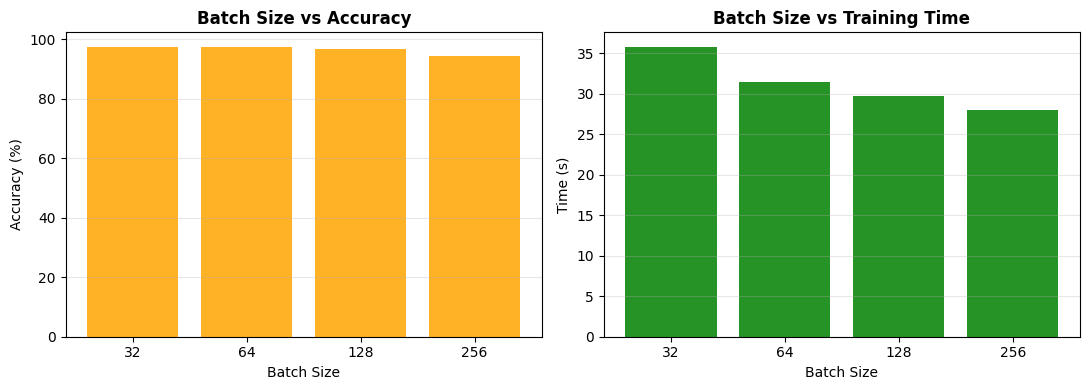

In [27]:
# ---- Batch Size Experiment ----
print("\n📌 Batch Size Experiment (LSTM, 2 epochs)")
print("-" * 60)

batch_results = {}
for bs in [32, 64, 128, 256]:
    # Create new data loaders with different batch size
    tr_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    te_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False)
    
    model = LSTMModel(28, 128, 1, 10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start = time.time()
    train_model(model, tr_loader, criterion, optimizer, num_epochs=2)
    elapsed = time.time() - start
    acc, _, _ = evaluate_model(model, te_loader)
    batch_results[str(bs)] = {'acc': acc, 'time': elapsed}
    print(f"  BatchSize={bs:3d} → Acc: {acc:.2f}% | Time: {elapsed:.1f}s")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(batch_results.keys(), [v['acc'] for v in batch_results.values()], color='orange', alpha=0.85)
ax1.set_title('Batch Size vs Accuracy', fontweight='bold')
ax1.set_xlabel('Batch Size'); ax1.set_ylabel('Accuracy (%)')
ax1.grid(True, alpha=0.3, axis='y')

ax2.bar(batch_results.keys(), [v['time'] for v in batch_results.values()], color='green', alpha=0.85)
ax2.set_title('Batch Size vs Training Time', fontweight='bold')
ax2.set_xlabel('Batch Size'); ax2.set_ylabel('Time (s)')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## 📊 Problem Statement 7: Comprehensive Comparison

### Final Results Table — All Models

In [28]:
# ---- Final Comparison Table ----
print("\n" + "=" * 70)
print(f"{'Model':<35} {'Accuracy':>10} {'Time(s)':>10} {'Params':>12}")
print("=" * 70)

for model_name, vals in results.items():
    print(f"{model_name:<35} {vals['acc']:>9.2f}% {vals['time']:>9.1f}s {vals['params']:>12,}")

print("=" * 70)


Model                                 Accuracy    Time(s)       Params
RNN L1 H64                              91.19%      40.3s        6,666
RNN L1 H128                             94.10%      38.9s       21,514
RNN L2 H128                             93.74%      40.0s       54,538
RNN L3 H128                             95.88%      40.4s       87,562
RNN L1 H256                             94.96%      40.6s       75,786
LSTM L1 H64 D0.0                        97.03%      39.8s       24,714
LSTM L1 H128 D0.0                       97.33%      40.8s       82,186
LSTM L2 H128 D0.2                       98.20%      46.0s      214,282
LSTM L2 H128 D0.3                       98.17%      45.7s      214,282
LSTM L3 H128 D0.3                       98.43%      50.9s      346,378
LSTM L1 H256 D0.0                       97.91%      44.5s      295,434
GRU L1 H64                              97.36%      39.4s       18,698
GRU L1 H128                             98.10%      39.1s       61,962
GRU L

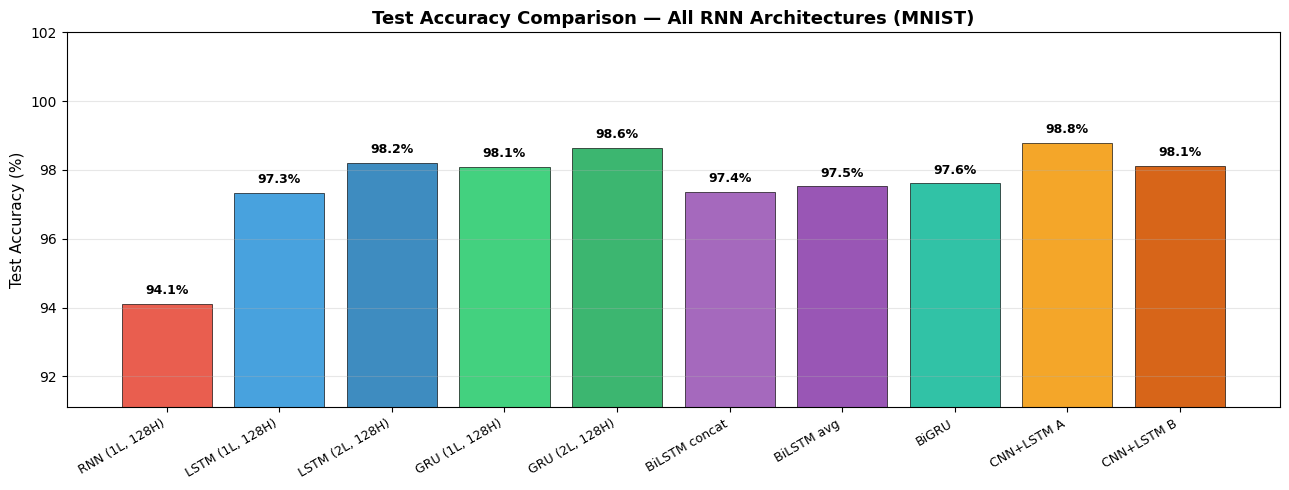

In [29]:
# ---- Accuracy Comparison Bar Chart ----
# Select representative models for clarity
representative = {
    'RNN (1L, 128H)':  results.get('RNN L1 H128', {}).get('acc', 0),
    'LSTM (1L, 128H)': results.get('LSTM L1 H128 D0.0', {}).get('acc', 0),
    'LSTM (2L, 128H)': results.get('LSTM L2 H128 D0.2', {}).get('acc', 0),
    'GRU (1L, 128H)':  results.get('GRU L1 H128', {}).get('acc', 0),
    'GRU (2L, 128H)':  results.get('GRU L2 H128', {}).get('acc', 0),
    'BiLSTM concat':   results.get('BiLSTM L1 concat', {}).get('acc', 0),
    'BiLSTM avg':      results.get('BiLSTM L1 avg', {}).get('acc', 0),
    'BiGRU':           results.get('BiGRU L1', {}).get('acc', 0),
    'CNN+LSTM A':      results.get('CNN+LSTM (Arch A)', {}).get('acc', 0),
    'CNN+LSTM B':      results.get('CNN+LSTM (Arch B)', {}).get('acc', 0),
}
# Remove zeros (models not yet run)
representative = {k: v for k, v in representative.items() if v > 0}

colors = ['#e74c3c', '#3498db', '#2980b9', '#2ecc71', '#27ae60',
          '#9b59b6', '#8e44ad', '#1abc9c', '#f39c12', '#d35400']

plt.figure(figsize=(13, 5))
bars = plt.bar(representative.keys(), representative.values(), 
               color=colors[:len(representative)], alpha=0.9, edgecolor='black', linewidth=0.5)

# Add value labels on top
for bar, val in zip(bars, representative.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Test Accuracy Comparison — All RNN Architectures (MNIST)', 
          fontsize=13, fontweight='bold')
plt.ylabel('Test Accuracy (%)', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylim([min(representative.values()) - 3, 102])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

---
## 📬 BONUS: EMNIST Letters Dataset

Now let's try the same best model on **EMNIST-Letters** (26 classes: A-Z)

In [30]:
# ---- Load EMNIST Letters ----
emnist_train = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',    # A-Z letters
    train=True,
    download=True,
    transform=transform
)

emnist_test = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',
    train=False,
    download=True,
    transform=transform
)

emnist_train_loader = DataLoader(emnist_train, batch_size=BATCH_SIZE, shuffle=True)
emnist_test_loader  = DataLoader(emnist_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"EMNIST Train: {len(emnist_train)} | Test: {len(emnist_test)}")
print(f"Classes: {emnist_train.classes}")

100%|██████████| 562M/562M [00:02<00:00, 220MB/s]  


EMNIST Train: 124800 | Test: 20800
Classes: ['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


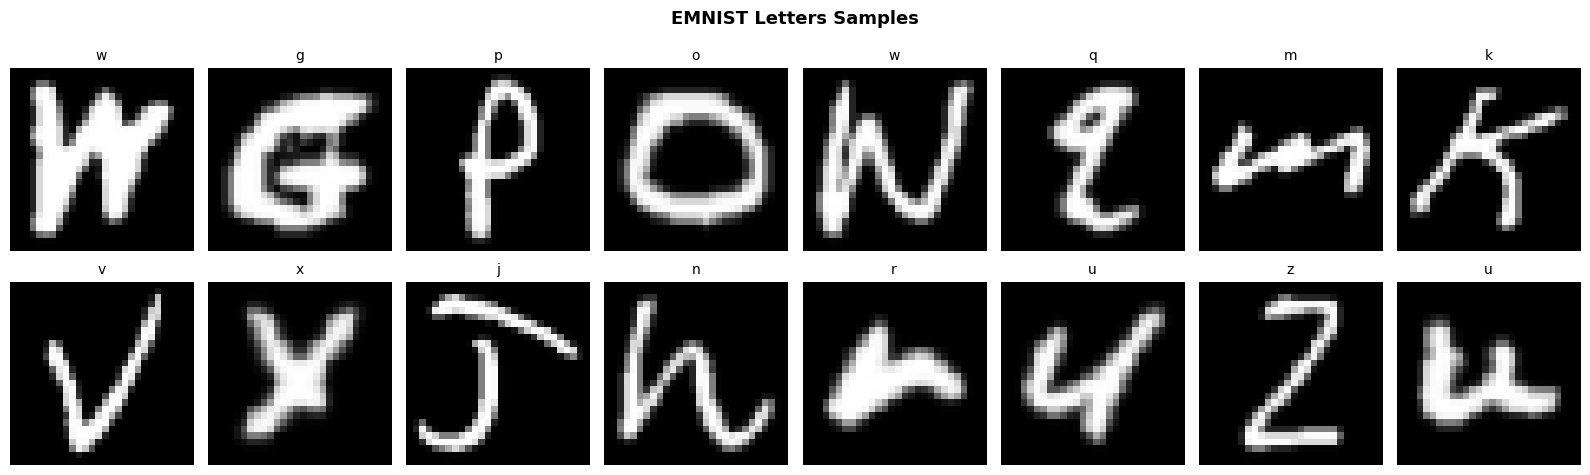

In [31]:
# Visualize EMNIST samples
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    img, label = emnist_train[i]
    ax.imshow(img.squeeze().T, cmap='gray')  # EMNIST needs transpose!
    ax.set_title(emnist_train.classes[label], fontsize=10)
    ax.axis('off')
plt.suptitle('EMNIST Letters Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Training LSTM on EMNIST Letters (26 classes)
  Epoch [1/3] | Loss: 0.7420 | Acc: 77.49%
  Epoch [2/3] | Loss: 0.3125 | Acc: 90.03%
  Epoch [3/3] | Loss: 0.2533 | Acc: 91.72%
  ✅ Training Time: 106.2s

🎯 EMNIST Letters Test Accuracy: 92.20%


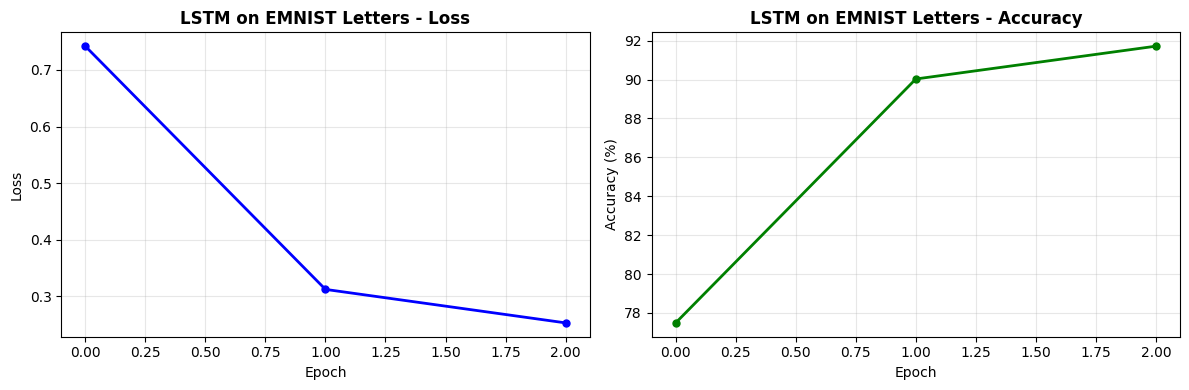

In [32]:
# ---- Train LSTM on EMNIST Letters (26 classes) ----
print("Training LSTM on EMNIST Letters (26 classes)")

model_emnist = LSTMModel(
    input_size=28,
    hidden_size=128,
    num_layers=2,
    num_classes=27,   # EMNIST labels are 1-26, so we use 27 to be safe
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_emnist.parameters(), lr=0.001)

history_emnist, _ = train_model(
    model_emnist, emnist_train_loader, criterion, optimizer, num_epochs=3
)

acc_emnist, preds_e, labels_e = evaluate_model(model_emnist, emnist_test_loader)
print(f"\n🎯 EMNIST Letters Test Accuracy: {acc_emnist:.2f}%")

plot_curves(history_emnist, 'LSTM on EMNIST Letters')

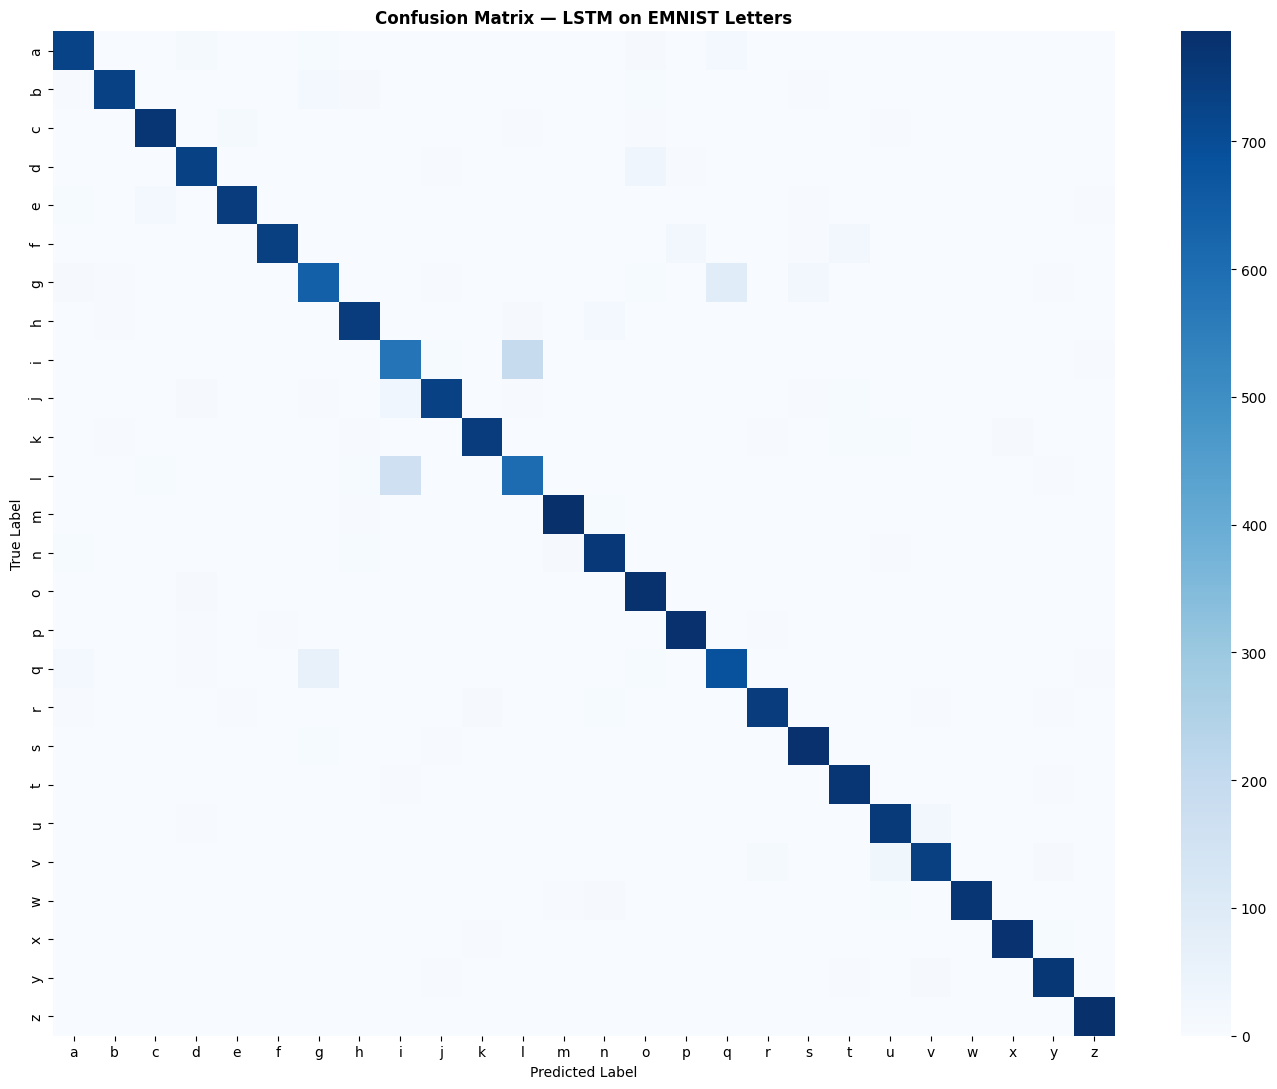

In [33]:
# Confusion matrix for EMNIST (show subset for readability)
# Filter to only the labels that appeared in test
unique_labels = sorted(set(labels_e))
class_names_emnist = [emnist_train.classes[i] for i in unique_labels]

cm = confusion_matrix(labels_e, preds_e, labels=unique_labels)
plt.figure(figsize=(14, 11))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names_emnist,
            yticklabels=class_names_emnist)
plt.title('Confusion Matrix — LSTM on EMNIST Letters', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()